In [1]:
import torch
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel


model_name="distilbert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(model_name)
model=AutoModel.from_pretrained(model_name)

model.eval()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [2]:
texts=[ "Luke Skywalker trained to become a Jedi.",
    "Darth Vader was once a powerful Jedi.",
    "The Millennium Falcon traveled across the galaxy.",
    "The Jedi used the Force to protect the galaxy.",
    "The Death Star was one of the Empire's most powerful weapons.",
    "Han Solo and Chewbacca flew across the galaxy together.",
    "The rebels planned a mission against the Galactic Empire.",
    "The battle between the Jedi and the Sith continued for years."]

print(texts)

['Luke Skywalker trained to become a Jedi.', 'Darth Vader was once a powerful Jedi.', 'The Millennium Falcon traveled across the galaxy.', 'The Jedi used the Force to protect the galaxy.', "The Death Star was one of the Empire's most powerful weapons.", 'Han Solo and Chewbacca flew across the galaxy together.', 'The rebels planned a mission against the Galactic Empire.', 'The battle between the Jedi and the Sith continued for years.']


In [3]:
inputs=tokenizer(texts,padding=True,truncation=True,return_tensors="pt")
print(inputs)

{'input_ids': tensor([[  101,  5355,  3712, 26965,  4738,  2000,  2468,  1037, 27273,  1012,
           102,     0,     0,     0,     0,     0],
        [  101, 14957,  2232, 12436,  4063,  2001,  2320,  1037,  3928, 27273,
          1012,   102,     0,     0,     0,     0],
        [  101,  1996, 10144, 11684,  6158,  2408,  1996,  9088,  1012,   102,
             0,     0,     0,     0,     0,     0],
        [  101,  1996, 27273,  2109,  1996,  2486,  2000,  4047,  1996,  9088,
          1012,   102,     0,     0,     0,     0],
        [  101,  1996,  2331,  2732,  2001,  2028,  1997,  1996,  3400,  1005,
          1055,  2087,  3928,  4255,  1012,   102],
        [  101,  7658,  3948,  1998, 21271,  3676, 16665,  5520,  2408,  1996,
          9088,  2362,  1012,   102,     0,     0],
        [  101,  1996,  8431,  3740,  1037,  3260,  2114,  1996, 21375,  3400,
          1012,   102,     0,     0,     0,     0],
        [  101,  1996,  2645,  2090,  1996, 27273,  1998,  1996,  413

In [6]:
import time

batch_sizes = [1, 2, 4, 8]

for batch_size in batch_sizes:
    batch = {
        key: value[:batch_size]
        for key, value in inputs.items()
    }

    start = time.time()

    with torch.no_grad():
        output = model(**batch)

    end = time.time()

    print("Batch size:", batch_size)
    print("Time taken:", end - start, "seconds")
    print()

Batch size: 1
Time taken: 0.19424057006835938 seconds

Batch size: 2
Time taken: 0.28635287284851074 seconds

Batch size: 4
Time taken: 0.487626314163208 seconds

Batch size: 8
Time taken: 0.8407459259033203 seconds



In [7]:
times = [0.19424057006835938, 0.28635287284851074, 0.487626314163208, 0.8407459259033203]
batch_sizes = [1, 2, 4, 8]

time_per_sample = []

for i in range(len(batch_sizes)):
    time = times[i] / batch_sizes[i]
    time_per_sample.append(time)

print(time_per_sample)

[0.19424057006835938, 0.14317643642425537, 0.121906578540802, 0.10509324073791504]


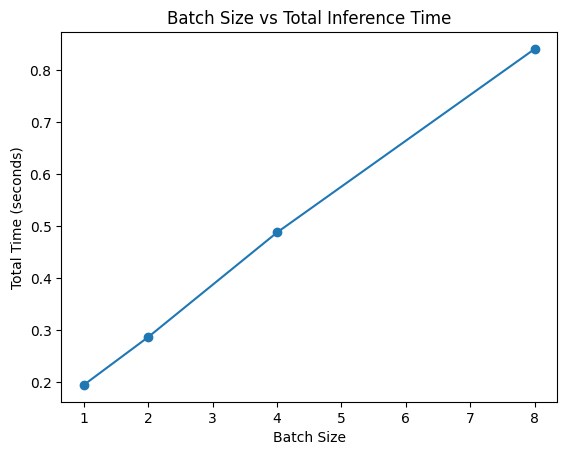

In [8]:
plt.plot(batch_sizes, times, marker='o')

plt.xlabel("Batch Size")
plt.ylabel("Total Time (seconds)")
plt.title("Batch Size vs Total Inference Time")

plt.show()

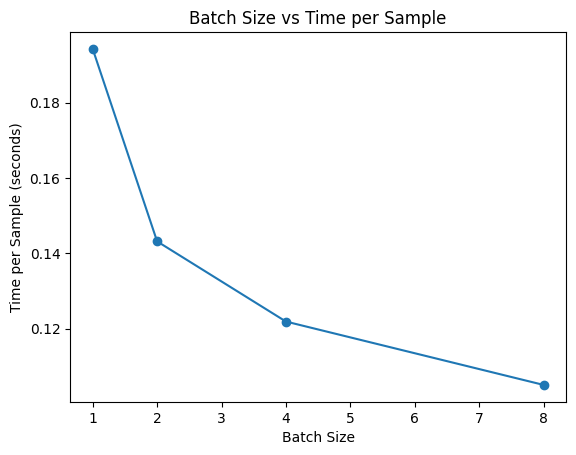

In [9]:
plt.plot(batch_sizes, time_per_sample, marker='o')

plt.xlabel("Batch Size")
plt.ylabel("Time per Sample (seconds)")
plt.title("Batch Size vs Time per Sample")

plt.show()

In [10]:
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

print(quantized_model)

/tmp/ipykernel_896/2851180232.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (k_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (v_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (out_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_l

In [11]:
torch.save(model.state_dict(), "original_model.pth")
torch.save(quantized_model.state_dict(), "quantized_model.pth")

import os

original_size = os.path.getsize("original_model.pth") / (1024 * 1024)
quantized_size = os.path.getsize("quantized_model.pth") / (1024 * 1024)

print("Original model size:", original_size, "MB")
print("Quantized model size:", quantized_size, "MB")

Original model size: 253.19033527374268 MB
Quantized model size: 131.71727657318115 MB


the original model is 253.19 and the quantized model is 131.71

In [13]:
import time
start = time.time()

with torch.no_grad():
    output = model(**inputs)

end = time.time()

original_time = end - start

print("Original model inference time:", original_time, "seconds")

Original model inference time: 0.530982494354248 seconds


In [14]:
start = time.time()

with torch.no_grad():
    output = quantized_model(**inputs)

end = time.time()

quantized_time = end - start

print("Quantized model inference time:", quantized_time, "seconds")


Quantized model inference time: 0.8362796306610107 seconds


In [15]:
import time

runs = 5

# Original model
original_times = []

for i in range(runs):
    start = time.time()

    with torch.no_grad():
        output = model(**inputs)

    end = time.time()
    original_times.append(end - start)

# Quantized model
quantized_times = []

for i in range(runs):
    start = time.time()

    with torch.no_grad():
        output = quantized_model(**inputs)

    end = time.time()
    quantized_times.append(end - start)

# Calculate averages
original_average = sum(original_times) / runs
quantized_average = sum(quantized_times) / runs

print("Original model average time:", original_average, "seconds")
print("Quantized model average time:", quantized_average, "seconds")

Original model average time: 0.7311371803283692 seconds
Quantized model average time: 0.35407114028930664 seconds


the quantized model took about half the time coompared to the original model, the original model took 0.73 seconds where as the quantized model took 0.35 seconds
